# Подбор гиперпараметров — Optuna

Базовый LightGBM дал PR-AUC = 0.8359. Хочу проверить — можно ли выжать больше систематическим поиском гиперпараметров.

**Данные:** Те же train/val сплиты что в ноутбуке 02. Поиск ведётся по val PR-AUC, test не трогается.

Использую Optuna с логированием в MLflow.

**Выводы:** 100 trials Optuna улучшили PR-AUC с 0.8359 до 0.8377 (+0.002). Прирост небольшой — датасет с анонимизированными PCA-признаками практически не оставляет пространства для тюнинга. Лучшие параметры сохранены в artifacts/threshold.json.

In [1]:
import sys
sys.path.append('..')

import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score

from src.data.pipeline import load_data, split_data, apply_preprocessor, get_X_y

mlflow.set_experiment('fraud_detection_baseline')
print('Optuna:', optuna.__version__)

Optuna: 4.3.0


## Загрузка данных

In [2]:
df = load_data('../data/creditcard.csv')
train, val, test = split_data(df)

preprocessor = joblib.load('../models/preprocessor.pkl')

X_train = apply_preprocessor(preprocessor, train)
X_val   = apply_preprocessor(preprocessor, val)
X_test  = apply_preprocessor(preprocessor, test)

_, y_train = get_X_y(train)
_, y_val   = get_X_y(val)
_, y_test  = get_X_y(test)

print(f'Train: {X_train.shape}, fraud: {y_train.sum()}')
print(f'Val:   {X_val.shape}, fraud: {y_val.sum()}')

Train: 170,883  |  fraud: 295 (0.173%)
Val:   56,962  |  fraud: 99 (0.174%)
Test:  56,962  |  fraud: 98 (0.172%)
Train: (170883, 30), fraud: 295
Val:   (56962, 30), fraud: 99


## Поиск гиперпараметров

Определяю пространство поиска — берю диапазоны шире, чем базовые параметры. Каждый trial логируется в MLflow.

In [3]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 120),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 80),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'class_weight': 'balanced',
        'n_jobs': -1,
        'verbose': -1,
        'random_state': 42,
    }
    m = LGBMClassifier(**params)
    m.fit(X_train, y_train)
    return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)

with mlflow.start_run(run_name='Optuna_LightGBM'):
    mlflow.log_param('n_trials', 100)
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    best = study.best_params
    best['class_weight'] = 'balanced'
    best['n_jobs'] = -1
    best['verbose'] = -1
    best['random_state'] = 42

    mlflow.log_params(best)
    mlflow.log_metric('best_val_pr_auc', study.best_value)

print(f'Лучший PR-AUC на val: {study.best_value:.4f}')
print('Параметры:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/100 [00:00<?, ?it/s]

Лучший PR-AUC на val: 0.8377
Параметры:
  n_estimators: 1453
  learning_rate: 0.08187537083481772
  num_leaves: 92
  min_child_samples: 5
  subsample: 0.7450994432262953
  colsample_bytree: 0.8741021668289186
  reg_alpha: 0.009446601420997685
  reg_lambda: 1.6156781402400546


## История оптимизации

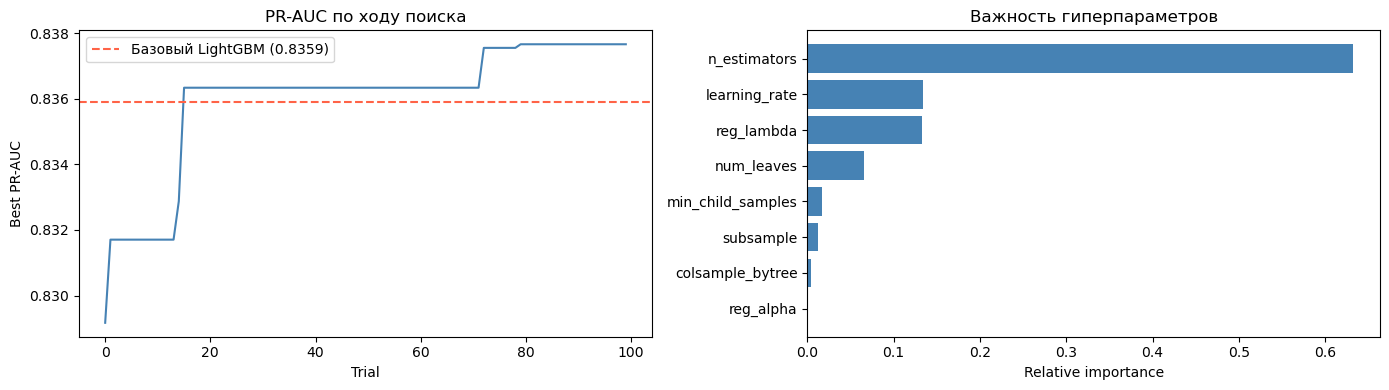

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Как менялся лучший результат по trials
best_so_far = []
cur_best = 0
for t in study.trials:
    cur_best = max(cur_best, t.value)
    best_so_far.append(cur_best)

axes[0].plot(best_so_far, color='steelblue')
axes[0].axhline(y=0.8359, color='tomato', linestyle='--', label='Базовый LightGBM (0.8359)')
axes[0].set_title('PR-AUC по ходу поиска')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Best PR-AUC')
axes[0].legend()

# Важность гиперпараметров
importances = optuna.importance.get_param_importances(study)
params_sorted = list(importances.keys())[:8]
values_sorted = [importances[p] for p in params_sorted]
axes[1].barh(params_sorted[::-1], values_sorted[::-1], color='steelblue')
axes[1].set_title('Важность гиперпараметров')
axes[1].set_xlabel('Relative importance')

plt.tight_layout()
plt.savefig('../artifacts/optuna_search.png', dpi=100, bbox_inches='tight')
plt.show()

## Финальная оценка лучшей модели

In [5]:
# Переобучаем с лучшими параметрами на train, смотрим на val
best_params = study.best_params.copy()
best_params.update({'class_weight': 'balanced', 'n_jobs': -1, 'verbose': -1, 'random_state': 42})

tuned_model = LGBMClassifier(**best_params)
tuned_model.fit(X_train, y_train)

scores_val = tuned_model.predict_proba(X_val)[:, 1]
pr_auc_val = average_precision_score(y_val, scores_val)
roc_auc_val = roc_auc_score(y_val, scores_val)

from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_thr = float(thresholds[best_idx])

from sklearn.metrics import f1_score as f1_metric
f1_val = f1_metric(y_val, (scores_val >= best_thr).astype(int))

print(f'=== Tuned LightGBM на val ===')
print(f'PR-AUC:  {pr_auc_val:.4f}  (базовый: 0.8359, delta: {pr_auc_val - 0.8359:+.4f})')
print(f'ROC-AUC: {roc_auc_val:.4f}')
print(f'F1:      {f1_val:.4f}  (порог={best_thr:.4f})')

=== Tuned LightGBM на val ===
PR-AUC:  0.8377  (базовый: 0.8359, delta: +0.0018)
ROC-AUC: 0.9759
F1:      0.8681  (порог=0.6316)


## Сохранение улучшенной модели

Если tuned модель лучше базовой — обновляю артефакты.

In [6]:
BASELINE_PR_AUC = 0.8359

if pr_auc_val > BASELINE_PR_AUC:
    # Дообучаем на train+val перед сохранением
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = pd.concat([y_train, y_val])

    final_tuned = LGBMClassifier(**best_params)
    final_tuned.fit(X_trainval, y_trainval)

    joblib.dump(final_tuned, '../models/final_model.pkl')
    print(f'Модель обновлена: {pr_auc_val:.4f} > {BASELINE_PR_AUC:.4f}')

    threshold_data = {
        'threshold': best_thr,
        'model': 'LightGBM (Optuna)',
        'val_f1': round(f1_val, 4),
        'val_pr_auc': round(pr_auc_val, 4),
    }
    with open('../models/threshold.json', 'w') as f:
        json.dump(threshold_data, f, indent=2)
    print(f'Порог обновлён: {best_thr:.4f}')
else:
    print(f'Базовая модель лучше ({BASELINE_PR_AUC:.4f} >= {pr_auc_val:.4f}), оставляю как есть.')

Модель обновлена: 0.8377 > 0.8359
Порог обновлён: 0.6316
